# GBD paper

## Reconstruct tables as preprint

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('sbod_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322056 entries, 0 to 322055
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           322056 non-null  int64
 1   Cause          322056 non-null  str  
 2   Location       322056 non-null  str  
 3   Age            322056 non-null  str  
 4   Sex            322056 non-null  str  
 5   RAG            322056 non-null  str  
 6   Measure        322056 non-null  str  
 7   Value          322056 non-null  str  
 8   Small numbers  322056 non-null  str  
dtypes: int64(1), str(8)
memory usage: 22.1 MB


In [3]:
sorted(df["Location"].unique().tolist())

['Aberdeen City',
 'Aberdeenshire',
 'Moray',
 'NHS Grampian',
 'North',
 'Scotland']

In [4]:
grampian_mask = df["Location"].str.contains("Grampian")
df.loc[grampian_mask, "Location"] = "Grampian"

north_mask = df["Location"].str.contains("North")
df.loc[north_mask, "Location"] = "North Scotland"

We focus only on Grampian region first and then extend to other locations.

In [5]:
location = "North Scotland"

In [6]:
# We're looking only at the DALY rate for now, so let's filter the data accordingly.
df1 = df[df["RAG"] == "DALY rate"]

# # Let's filter out the required causes
# causes = ["Alzheimer's disease and other dementias", 'Atrial fibrillation and flutter', 'Ischaemic heart disease', 'Cerebrovascular disease', 'Low back and neck pain',
#           'Lung cancer', 'Headache disorders', 'Chronic obstructive pulmonary disease', 'Breast cancer', 'Depression', 'Anxiety disorders',
#           'Other cancers', 'Other cardiovascular and circulatory diseases', 'Drug use disorders', 'Lower respiratory infections',
#           'Diabetes mellitus', 'Other musculoskeletal disorders', 'Osteoarthritis', 'Cirrhosis and other chronic liver diseases',
#           'Chronic kidney disease', 'Skin and subcutaneous diseases', 'Other digestive diseases', 'Gynecological diseases', 'Asthma',
#           'Self-harm and interpersonal violence', 'Falls']
# print(f"Filtering the data for the {len(causes)} causes")
# df1 = df1[df1["Cause"].isin(causes)]

# Remove only the "All causes" row, which is not relevant to our analysis
df1 = df1[df1["Cause"] != "All causes of disease and injury"]

# Let's filter out the required locations
df1 = df1[df1["Location"].isin([location, "Scotland"])]

df1.info()

<class 'pandas.DataFrame'>
Index: 17640 entries, 161082 to 319493
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Year           17640 non-null  int64
 1   Cause          17640 non-null  str  
 2   Location       17640 non-null  str  
 3   Age            17640 non-null  str  
 4   Sex            17640 non-null  str  
 5   RAG            17640 non-null  str  
 6   Measure        17640 non-null  str  
 7   Value          17640 non-null  str  
 8   Small numbers  17640 non-null  str  
dtypes: int64(1), str(8)
memory usage: 1.3 MB


In [7]:
df1.nunique()

Year                6
Cause              70
Location            2
Age                 7
Sex                 3
RAG                 1
Measure          7937
Value               2
Small numbers       3
dtype: int64

In [8]:
cols_to_drop = ["RAG", "Value", "Small numbers"]
df1 = df1.drop(columns=cols_to_drop)
df1 = df1.rename(columns={"Measure": "DALY rate"})
df1.info()

<class 'pandas.DataFrame'>
Index: 17640 entries, 161082 to 319493
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       17640 non-null  int64
 1   Cause      17640 non-null  str  
 2   Location   17640 non-null  str  
 3   Age        17640 non-null  str  
 4   Sex        17640 non-null  str  
 5   DALY rate  17640 non-null  str  
dtypes: int64(1), str(5)
memory usage: 964.7 KB


In [9]:
df1["Age"].unique().tolist()

['Under 15',
 '15 to 24',
 '25 to 44',
 '45 to 64',
 '65 to 84',
 '85 and over',
 'All ages']

In [10]:
df1[(df1["Year"] == 2019) & (df1["Cause"] == "Alzheimer's disease and other dementias") & (df1["Sex"] == "Female")]

,Year,Cause,Location,Age,Sex,DALY rate
278160,2019,Alzheimer's disease and other dementias,Scotland,Under 15,Female,22.4
278161,2019,Alzheimer's disease and other dementias,Scotland,15 to 24,Female,0.0
278162,2019,Alzheimer's disease and other dementias,Scotland,25 to 44,Female,2.3
278163,2019,Alzheimer's disease and other dementias,Scotland,45 to 64,Female,130.1
278164,2019,Alzheimer's disease and other dementias,Scotland,65 to 84,Female,"5,154.6"
278165,2019,Alzheimer's disease and other dementias,Scotland,85 and over,Female,"36,474.9"
281994,2019,Alzheimer's disease and other dementias,North Scotland,Under 15,Female,3.0
281995,2019,Alzheimer's disease and other dementias,North Scotland,15 to 24,Female,0.0
281996,2019,Alzheimer's disease and other dementias,North Scotland,25 to 44,Female,2.1
281997,2019,Alzheimer's disease and other dementias,North Scotland,45 to 64,Female,63.7


In [11]:
daly_df = df1[df1["Age"] == "All ages"].drop(columns=["Age"])
daly_df.info()

<class 'pandas.DataFrame'>
Index: 2520 entries, 299061 to 319493
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       2520 non-null   int64
 1   Cause      2520 non-null   str  
 2   Location   2520 non-null   str  
 3   Sex        2520 non-null   str  
 4   DALY rate  2520 non-null   str  
dtypes: int64(1), str(4)
memory usage: 118.1 KB


In [12]:
daly_df[daly_df["Cause"] == "Alzheimer's disease and other dementias"]

,Year,Cause,Location,Sex,DALY rate
299403,2014,Alzheimer's disease and other dementias,Scotland,Male,"1,424.3"
299404,2014,Alzheimer's disease and other dementias,Scotland,Female,"1,631.0"
299405,2014,Alzheimer's disease and other dementias,Scotland,Both sexes,"1,563.0"
300042,2014,Alzheimer's disease and other dementias,North Scotland,Male,"1,299.7"
300043,2014,Alzheimer's disease and other dementias,North Scotland,Female,"1,446.0"
300044,2014,Alzheimer's disease and other dementias,North Scotland,Both sexes,"1,403.9"
303237,2015,Alzheimer's disease and other dementias,Scotland,Male,"1,605.4"
303238,2015,Alzheimer's disease and other dementias,Scotland,Female,"1,824.4"
303239,2015,Alzheimer's disease and other dementias,Scotland,Both sexes,"1,757.4"
303876,2015,Alzheimer's disease and other dementias,North Scotland,Male,"1,475.2"


In [13]:
daly_df["location_yr"] = daly_df["Location"] + "_" + daly_df["Year"].astype(str)
daly_df["daly_int"] = (
    pd.to_numeric(
        daly_df["DALY rate"].astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )
    .round()
    .astype("Int64")
)
tables = {}
for gender in daly_df["Sex"].unique():
    # Filter the data for the current gender
    filtered_df = daly_df[daly_df["Sex"] == gender]
    
    # Pivot the data to have causes as columns and location-year combinations as rows
    pivoted_df = pd.pivot_table(
        filtered_df,
        index='Cause',
        columns='location_yr',
        values='daly_int',
        aggfunc='first' # Use 'sum' or 'mean' if you have duplicate rows for the same condition/location/year
    ).reset_index()

    # Clean up the axis label (removes the 'location_year' label floating above the columns)
    pivoted_df.columns.name = None
    
    # Save the table in our dictionary
    tables[gender] = pivoted_df

In [14]:
cols = ["Cause", "Scotland_2019", f"{location}_2014", f"{location}_2015", f"{location}_2016", f"{location}_2017", f"{location}_2018", f"{location}_2019"]
m_df = tables["Male"][cols]
f_df = tables["Female"][cols]
# b_df = tables["Both sexes"][cols]

We sort them by Scotland's value and retain the top 25 causes in location according to 2019 value.

In [15]:
f_df[f"{location}_diff"] = f_df["Scotland_2019"] - f_df[f"{location}_2019"]

# Retain only the top 25 causes for our analysis
top = 25
f_df_scot = f_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True).head(top)
f_df_loc = f_df.sort_values(by=f"{location}_2019", ascending=False).reset_index(drop=True).head(top)

f_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff
0,Age-related and other hearing loss,310,323,323,323,321,321,321,-11
1,Alcohol use disorders,312,322,245,241,250,291,225,87
2,Alzheimer's disease and other dementias,1827,1446,1701,1616,1726,1729,1680,147
3,Anxiety disorders,1045,960,960,958,976,976,975,70
4,Asthma,330,327,370,346,354,333,327,3


In [16]:
a = """Alzheimer's disease and other dementias
Ischaemic heart disease
Cerebrovascular disease
Low back and neck pain
Lung cancer
Headache disorders
Chronic obstructive pulmonary disease
Breast cancer
Depression
Anxiety disorders
Other cancers
Other cardiovascular and circulatory diseases
Colorectal cancer
Drug use disorders
Lower respiratory infections
Diabetes mellitus
Other musculoskeletal disorders
Osteoarthritis
Cirrhosis and other chronic liver diseases
Chronic kidney disease
Skin and subcutaneous diseases
Other digestive diseases
Gynecological diseases
Asthma
Self-harm and interpersonal violence
Falls"""

b = set(a.split("\n"))
c = set(f_df_scot["Cause"].tolist()).union(set(f_df_loc["Cause"].tolist()))
print("Causes in the top 25 list but not in the original list:")
print(b - c)
print("\nCauses in the original list but not in the top 25 list:")
print(c - b)

Causes in the top 25 list but not in the original list:
{'Asthma'}

Causes in the original list but not in the top 25 list:
{'Endocrine, metabolic, blood, and immune disorders'}


In [17]:
p = set(f_df_scot["Cause"].tolist())
q = set(f_df_loc["Cause"].tolist())
print(f"Causes in the top 25 list for Scotland but not for the {location}:")
print(p - q)
print(f_df_scot.index[f_df_scot["Cause"].isin(list(p-q))].tolist())
print(f"\nCauses in the top 25 list for the {location} but not for Scotland:")
print(q - p)
print(f_df_loc.index[f_df_loc["Cause"].isin(list(q-p))].tolist())

Causes in the top 25 list for Scotland but not for the North Scotland:
{'Chronic kidney disease'}
[22]

Causes in the top 25 list for the North Scotland but not for Scotland:
{'Endocrine, metabolic, blood, and immune disorders'}
[22]


In [18]:
f_df1 = f_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
f_df1.shape

(70, 9)

In [19]:
top_25_causes_female = set(f_df_scot["Cause"].tolist()).union(set(f_df_loc["Cause"].tolist()))
f_df = f_df[f_df["Cause"].isin(top_25_causes_female)].sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
f_df.shape

(26, 9)

In [20]:
m_df[f"{location}_diff"] = m_df["Scotland_2019"] - m_df[f"{location}_2019"]

# Retain only the top 25 causes for our analysis
m_df_scot = m_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True).head(top)
m_df_loc = m_df.sort_values(by=f"{location}_2019", ascending=False).reset_index(drop=True).head(top)

m_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff
0,Age-related and other hearing loss,327,340,340,339,338,338,338,-11
1,Alcohol use disorders,863,814,860,822,772,834,746,117
2,Alzheimer's disease and other dementias,1639,1300,1475,1381,1528,1544,1578,61
3,Anxiety disorders,646,578,578,578,591,591,590,56
4,Asthma,259,250,265,320,251,245,263,-4


In [21]:
a = """Ischaemic heart disease
Lung cancer
Alzheimer's disease and other dementias
Cerebrovascular disease
Drug use disorders
Chronic obstructive pulmonary disease
Other cancers
Depression
Low back and neck pain
Diabetes mellitus
Colorectal cancer
Self-harm and interpersonal violence
Other cardiovascular and circulatory diseases
Lower respiratory infections
Prostate cancer
Headache disorders
Oesophageal cancer
Alcohol use disorders
Anxiety disorders
Cirrhosis and other chronic liver diseases
Atrial fibrillation and flutter
Chronic kidney disease
Other musculoskeletal disorders
Other digestive diseases
Pancreatic cancer
Other chronic respiratory diseases
Falls"""

b = set(a.split("\n"))
c = set(m_df_scot["Cause"].tolist()).union(set(m_df_loc["Cause"].tolist()))
print("Causes in the top 25 list but not in the original list:")
print(b - c)
print("\nCauses in the original list but not in the top 25 list:")
print(c - b)

Causes in the top 25 list but not in the original list:
{'Pancreatic cancer'}

Causes in the original list but not in the top 25 list:
set()


In [22]:
p = set(m_df_scot["Cause"].tolist())
q = set(m_df_loc["Cause"].tolist())
print(f"Causes in the top 25 list for Scotland but not for the {location}:")
print(p - q)
print(m_df_scot.index[m_df_scot["Cause"].isin(list(p-q))].tolist())
print(f"\nCauses in the top 25 list for the {location} but not for Scotland:")
print(q - p)
print(m_df_loc.index[m_df_loc["Cause"].isin(list(q-p))].tolist())

Causes in the top 25 list for Scotland but not for the North Scotland:
{'Other chronic respiratory diseases'}
[23]

Causes in the top 25 list for the North Scotland but not for Scotland:
{'Other musculoskeletal disorders'}
[21]


In [23]:
top_25_causes_male = set(m_df_scot["Cause"].tolist()).union(set(m_df_loc["Cause"].tolist()))
m_df = m_df[m_df["Cause"].isin(top_25_causes_male)].sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
m_df.shape

(26, 9)

In [24]:
# b_df[f"{location}_diff"] = b_df["Scotland_2019"] - b_df[f"{location}_2019"]
# b_df = b_df.sort_values(by="Scotland_2019", ascending=False).reset_index(drop=True)
# b_df.head()

In [25]:
m_df.to_csv("males_2014_2019.csv", index=False)
f_df.to_csv("females_2014_2019.csv", index=False)
# b_df.to_csv("both_sexes_2014_2019.csv", index=False)

In [26]:
def get_cagr(row, loc, base_yr, final_yr=2019):
    base_value = row[f"{loc}_{base_yr}"]
    final_value = row[f"{loc}_{final_yr}"]
    if base_value == 0:
        return 0
    cagr = 100*((final_value / base_value) ** (1 / (final_yr - base_yr)) - 1)
    return round(cagr,2)

In [27]:
threshold = 1

In [28]:
f_df[f"{location}_CAGR_2014"] = f_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
f_df[f"{location}_CAGR_2016"] = f_df.apply(lambda row: get_cagr(row, location, 2016), axis=1)
f_df[f"{location}_inclusion_change"] = f_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2016"]) < 0 else "No", axis=1)

In [29]:
m_df[f"{location}_CAGR_2014"] = m_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
m_df[f"{location}_CAGR_2016"] = m_df.apply(lambda row: get_cagr(row, location, 2016), axis=1)
m_df[f"{location}_inclusion_change"] = m_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2016"]) < 0 else "No", axis=1)

In [30]:
# b_df[f"{location}_CAGR_2014"] = b_df.apply(lambda row: get_cagr(row, location, 2014), axis=1)
# b_df[f"{location}_CAGR_2016"] = b_df.apply(lambda row: get_cagr(row, location, 2016), axis=1)
# b_df[f"{location}_inclusion_change"] = b_df.apply(lambda row: "Yes" if (threshold - row[f"{location}_CAGR_2014"])*(1 - row[f"{location}_CAGR_2016"]) < 0 else "No", axis=1)

In [31]:
m_df.to_csv("males_2014_2019.csv", index=False)
f_df.to_csv("females_2014_2019.csv", index=False)
# b_df.to_csv("both_sexes_2014_2019.csv", index=False)

## Plots

First we show why CAGR is not a good metric for measuring growth

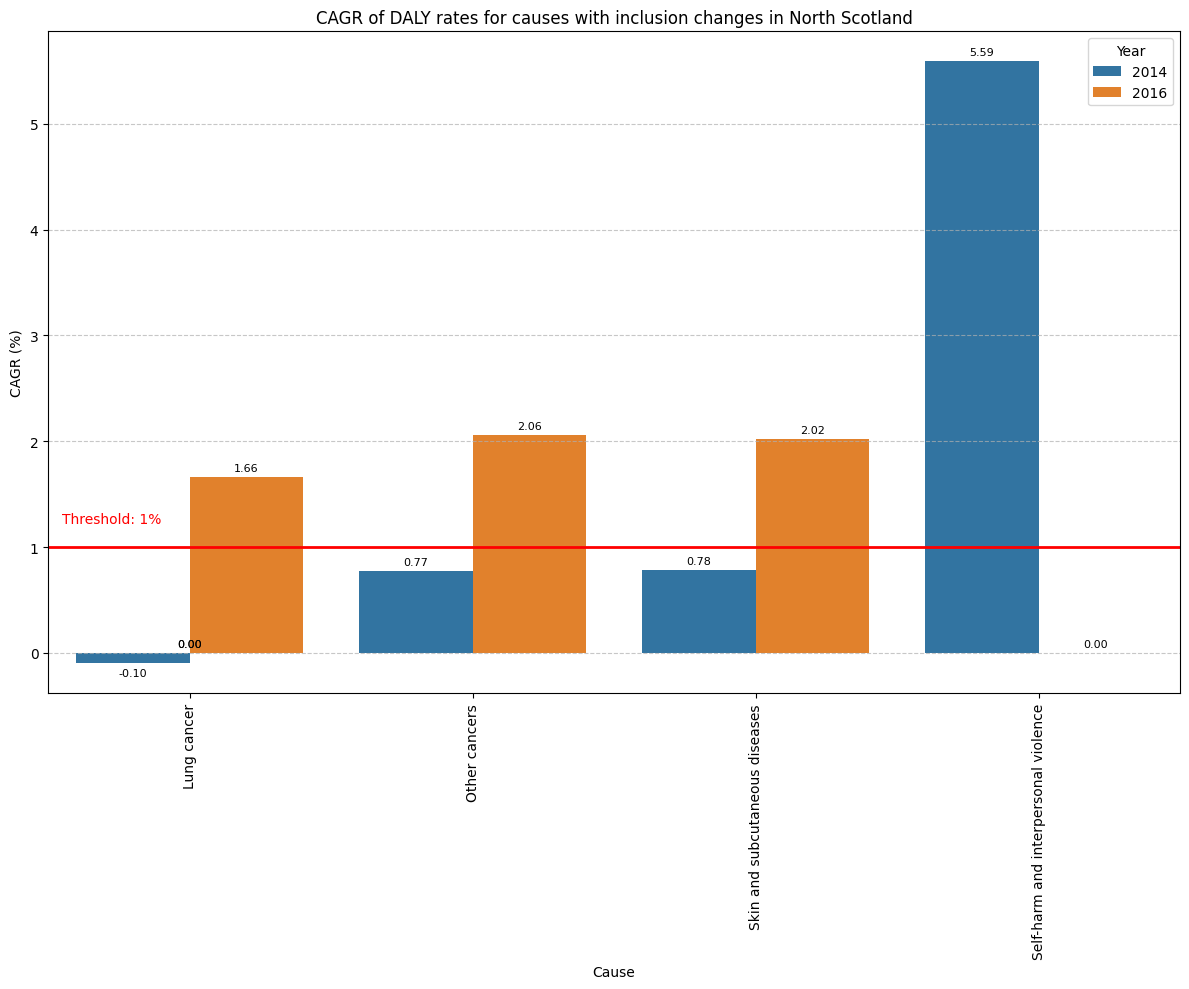

In [32]:
plot_df = f_df[f_df[f"{location}_inclusion_change"] == "Yes"][["Cause", f"{location}_CAGR_2014", f"{location}_CAGR_2016"]]
plot_df = plot_df.melt(id_vars="Cause", var_name="Year", value_name="CAGR")
plot_df["Year"] = plot_df["Year"].str.replace(f"{location}_CAGR_", "")

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=plot_df, x="Cause", y="CAGR", hue="Year")

# annotate each bar
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.2f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom" if h >= 0 else "top",
        xytext=(0, 3 if h >= 0 else -3),
        textcoords="offset points",
        fontsize=8
    )

plt.xticks(rotation=90)
plt.axhline(threshold, color="red", linestyle="-", linewidth=2)
plt.text(-0.45, threshold + 0.2, f"Threshold: {threshold}%", color="red", fontsize=10, ha="left", va="bottom")
plt.title(f"CAGR of DALY rates for causes with inclusion changes in {location}")
plt.xlabel("Cause")
plt.ylabel("CAGR (%)")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
f_df.shape, m_df.shape

((26, 12), (26, 12))

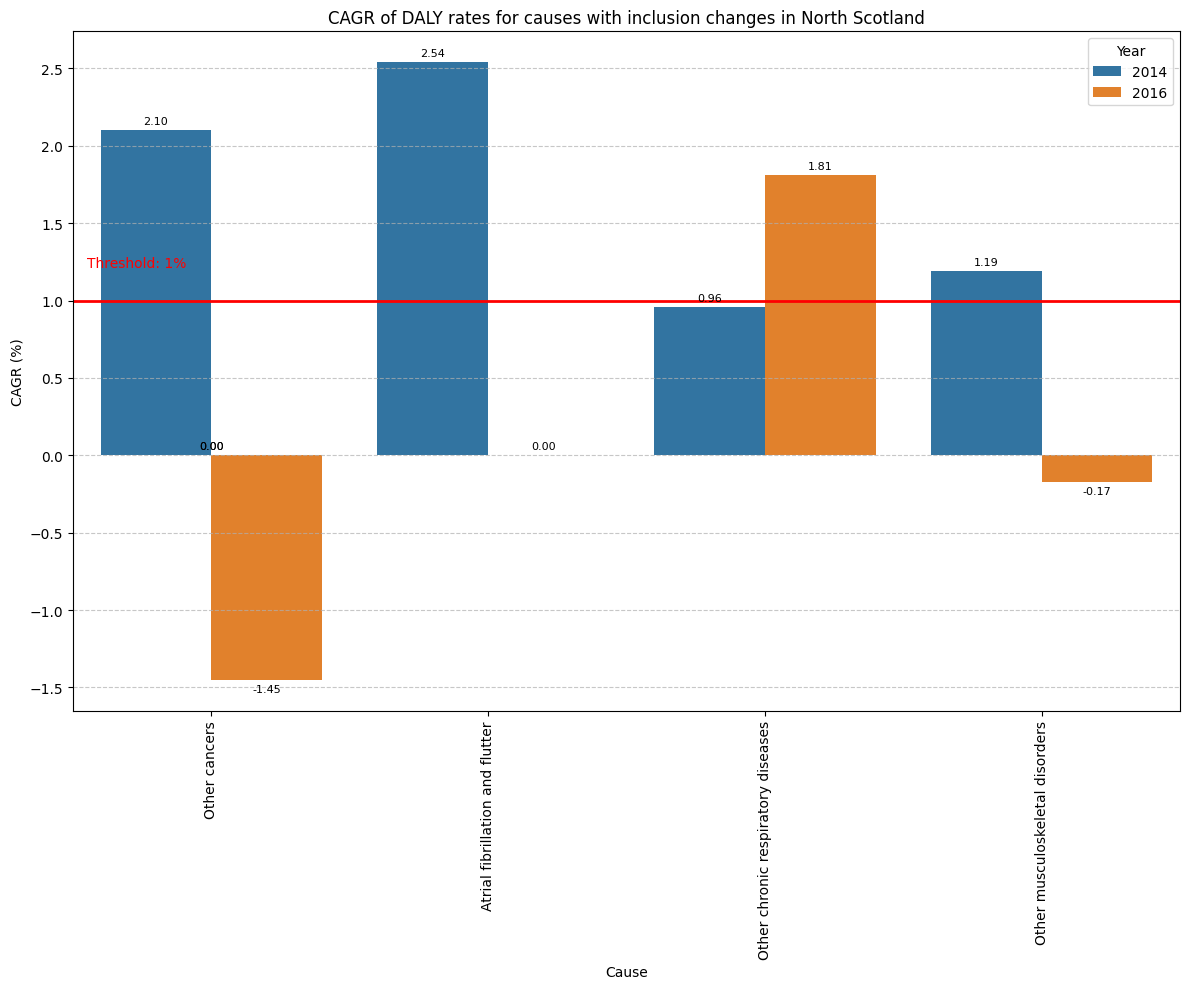

In [34]:
plot_df = m_df[m_df[f"{location}_inclusion_change"] == "Yes"][["Cause", f"{location}_CAGR_2014", f"{location}_CAGR_2016"]]
plot_df = plot_df.melt(id_vars="Cause", var_name="Year", value_name="CAGR")
plot_df["Year"] = plot_df["Year"].str.replace(f"{location}_CAGR_", "")

plt.figure(figsize=(12, 10))
ax = sns.barplot(data=plot_df, x="Cause", y="CAGR", hue="Year")

# annotate each bar
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.2f}",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom" if h >= 0 else "top",
        xytext=(0, 3 if h >= 0 else -3),
        textcoords="offset points",
        fontsize=8
    )

plt.xticks(rotation=90)
plt.axhline(threshold, color="red", linestyle="-", linewidth=2)
plt.text(-0.45, threshold + 0.2, f"Threshold: {threshold}%", color="red", fontsize=10, ha="left", va="bottom")
plt.title(f"CAGR of DALY rates for causes with inclusion changes in {location}")
plt.xlabel("Cause")
plt.ylabel("CAGR (%)")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### YoY growth

We use the following formula for YoY growth rate. For now we get the average across the 6 years. Later, we'll try weighted averaging weighting higher for the recent years.

$$g_t = \frac{Y_t - Y_{t-1}}{Y_{t-1}}$$

In [35]:
f_df[f"{location}_avg_yoy"] = f_df.apply(lambda row: round(100*np.mean([(row[f"{location}_{yr}"] - row[f"{location}_{yr-1}"])/row[f"{location}_{yr-1}"] for yr in range(2015, 2020)]), 2), axis=1)

f_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff,North Scotland_CAGR_2014,North Scotland_CAGR_2016,North Scotland_inclusion_change,North Scotland_avg_yoy
0,Alzheimer's disease and other dementias,1827,1446,1701,1616,1726,1729,1680,147,3.05,1.30,No,3.36
1,Ischaemic heart disease,1605,1604,1676,1491,1592,1511,1472,133,-1.70,-0.43,No,-1.49
2,Lung cancer,1474,1249,1316,1183,1248,1228,1243,231,-0.10,1.66,Yes,0.07
3,Low back and neck pain,1452,1421,1420,1420,1432,1432,1432,20,0.15,0.28,No,0.15
4,Cerebrovascular disease,1379,1444,1414,1450,1429,1313,1338,41,-1.51,-2.64,No,-1.44


In [36]:
m_df[f"{location}_avg_yoy"] = m_df.apply(lambda row: round(100*np.mean([(row[f"{location}_{yr}"] - row[f"{location}_{yr-1}"])/row[f"{location}_{yr-1}"] for yr in range(2015, 2020)]), 2), axis=1)

m_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff,North Scotland_CAGR_2014,North Scotland_CAGR_2016,North Scotland_inclusion_change,North Scotland_avg_yoy
0,Ischaemic heart disease,3713,3872,3676,3505,3744,3442,3493,220,-2.04,-0.11,No,-1.90
1,Drug use disorders,2367,1104,1209,1162,1607,1733,1616,751,7.92,11.62,No,9.00
2,Lung cancer,1749,1777,1807,1779,1673,1492,1557,192,-2.61,-4.35,No,-2.46
3,Alzheimer's disease and other dementias,1639,1300,1475,1381,1528,1544,1578,61,3.95,4.55,No,4.20
4,Cerebrovascular disease,1516,1584,1723,1698,1594,1464,1387,129,-2.62,-6.52,No,-2.44


In [37]:
# b_df[f"{location}_avg_yoy"] = b_df.apply(lambda row: round(100*np.mean([(row[f"{location}_{yr}"] - row[f"{location}_{yr-1}"])/row[f"{location}_{yr-1}"] for yr in range(2015, 2020)]), 2), axis=1)

# b_df.head()

In [38]:
m_df.to_csv("males_2014_2019.csv", index=False)
f_df.to_csv("females_2014_2019.csv", index=False)
# b_df.to_csv("both_sexes_2014_2019.csv", index=False)

## Thiel-Sen Quotient

In [39]:
import math

def get_pos(N, percentile=50):
    val = (percentile / 100) * (N - 1) # This gives us the position in a 0-indexed list
    return math.floor(val), val

In [40]:
N = 15
get_pos(N, 75)

(10, 10.5)

In [41]:
def get_tsq(x, y=None, q=2, norm_mode="mean"):
    # Supports:
    # 1) get_tsq({year: value, ...}, q=2)
    # 2) get_tsq([years...], [values...], q=2)
    if y is None:
        if not isinstance(x, dict):
            raise ValueError("If 'y' is None, 'x' must be a dict of {x: y}.")
        x_arr = np.asarray(list(x.keys()), dtype=float)
        y_arr = np.asarray(list(x.values()), dtype=float)
    else:
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)

    n = x_arr.size
    if n < 2:
        return 0.0

    # All pairwise slopes for i < j (vectorized)
    i, j = np.triu_indices(n, k=1)
    dx = x_arr[j] - x_arr[i]
    dy = y_arr[j] - y_arr[i]
    slopes = dy / dx  # dx != 0 for years

    # Percentile selection
    percentile = 50 if q == 2 else 75 if q == 3 else 50
    order = np.argsort(slopes)
    slopes_sorted = slopes[order]
    i_sorted = i[order]
    j_sorted = j[order]

    m = slopes_sorted.size
    ts_index, weight_val = get_pos(m, percentile)
    frac = weight_val - ts_index

    if ts_index >= m - 1:
        ts_slope = slopes_sorted[-1]
        frac = 0.0
    else:
        ts_slope = slopes_sorted[ts_index] + frac * (slopes_sorted[ts_index + 1] - slopes_sorted[ts_index])

    # Normalization constant
    if norm_mode == "mean":
        norm_const = y_arr.mean()
    elif norm_mode == "median":
        norm_const = np.median(y_arr)
    elif norm_mode == "specific":
        if frac == 0.0 or ts_index >= m - 1:
            yrs_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            yrs_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[yrs_idx].mean()
    else:
        raise ValueError("norm_mode must be one of: 'mean', 'median', 'specific'")

    return round(100 * ts_slope / norm_const, 2) if norm_const != 0 else 0.0

In [42]:
norm_modes = ["mean", "median", "specific"]

for norm_mode in norm_modes:
    f_df[f"{location}_tsq2_{norm_mode}"] = f_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
for norm_mode in norm_modes:
    f_df[f"{location}_tsq3_{norm_mode}"] = f_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
f_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff,North Scotland_CAGR_2014,North Scotland_CAGR_2016,North Scotland_inclusion_change,North Scotland_avg_yoy,North Scotland_tsq2_mean,North Scotland_tsq2_median,North Scotland_tsq2_specific,North Scotland_tsq3_mean,North Scotland_tsq3_median,North Scotland_tsq3_specific
0,Alzheimer's disease and other dementias,1827,1446,1701,1616,1726,1729,1680,147,3.05,1.30,No,3.36,1.29,1.26,1.29,4.72,4.61,4.88
1,Ischaemic heart disease,1605,1604,1676,1491,1592,1511,1472,133,-1.70,-0.43,No,-1.49,-2.50,-2.51,-2.61,-0.33,-0.33,-0.34
2,Lung cancer,1474,1249,1316,1183,1248,1228,1243,231,-0.10,1.66,Yes,0.07,-0.20,-0.20,-0.20,1.41,1.41,1.44
3,Low back and neck pain,1452,1421,1420,1420,1432,1432,1432,20,0.15,0.28,No,0.15,0.19,0.19,0.19,0.28,0.28,0.28
4,Cerebrovascular disease,1379,1444,1414,1450,1429,1313,1338,41,-1.51,-2.64,No,-1.44,-1.52,-1.49,-1.52,-0.07,-0.07,-0.07


In [43]:
for norm_mode in norm_modes:
    m_df[f"{location}_tsq2_{norm_mode}"] = m_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
for norm_mode in norm_modes:
    m_df[f"{location}_tsq3_{norm_mode}"] = m_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
m_df.head()

,Cause,Scotland_2019,North Scotland_2014,North Scotland_2015,North Scotland_2016,North Scotland_2017,North Scotland_2018,North Scotland_2019,North Scotland_diff,North Scotland_CAGR_2014,North Scotland_CAGR_2016,North Scotland_inclusion_change,North Scotland_avg_yoy,North Scotland_tsq2_mean,North Scotland_tsq2_median,North Scotland_tsq2_specific,North Scotland_tsq3_mean,North Scotland_tsq3_median,North Scotland_tsq3_specific
0,Ischaemic heart disease,3713,3872,3676,3505,3744,3442,3493,220,-2.04,-0.11,No,-1.90,-2.09,-2.11,-2.06,-0.49,-0.49,-0.51
1,Drug use disorders,2367,1104,1209,1162,1607,1733,1616,751,7.92,11.62,No,9.00,8.97,8.95,7.54,12.18,12.16,12.11
2,Lung cancer,1749,1777,1807,1779,1673,1492,1557,192,-2.61,-4.35,No,-2.46,-3.72,-3.62,-3.72,-1.86,-1.82,-1.78
3,Alzheimer's disease and other dementias,1639,1300,1475,1381,1528,1544,1578,61,3.95,4.55,No,4.20,2.76,2.70,3.02,4.83,4.72,4.90
4,Cerebrovascular disease,1516,1584,1723,1698,1594,1464,1387,129,-2.62,-6.52,No,-2.44,-4.89,-4.85,-5.40,-1.75,-1.73,-1.70


In [44]:
# for norm_mode in norm_modes:
#     b_df[f"{location}_tsq2_{norm_mode}"] = b_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=2, norm_mode=norm_mode), axis=1)
#     b_df[f"{location}_tsq3_{norm_mode}"] = b_df.apply(lambda row: get_tsq(list(range(2014, 2020)), [row[f"{location}_{yr}"] for yr in range(2014, 2020)], q=3, norm_mode=norm_mode), axis=1)
# b_df.head()

In [45]:
set(f_df.columns) == set(m_df.columns)

True

In [46]:
f_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Cause                            26 non-null     str    
 1   Scotland_2019                    26 non-null     Int64  
 2   North Scotland_2014              26 non-null     Int64  
 3   North Scotland_2015              26 non-null     Int64  
 4   North Scotland_2016              26 non-null     Int64  
 5   North Scotland_2017              26 non-null     Int64  
 6   North Scotland_2018              26 non-null     Int64  
 7   North Scotland_2019              26 non-null     Int64  
 8   North Scotland_diff              26 non-null     Int64  
 9   North Scotland_CAGR_2014         26 non-null     float64
 10  North Scotland_CAGR_2016         26 non-null     float64
 11  North Scotland_inclusion_change  26 non-null     str    
 12  North Scotland_avg_yoy           26

In [47]:
f_df.to_csv("females_2014_2019.csv", index=False)
m_df.to_csv("males_2014_2019.csv", index=False)
# b_df.to_csv("both_2014_2019.csv", index=False)

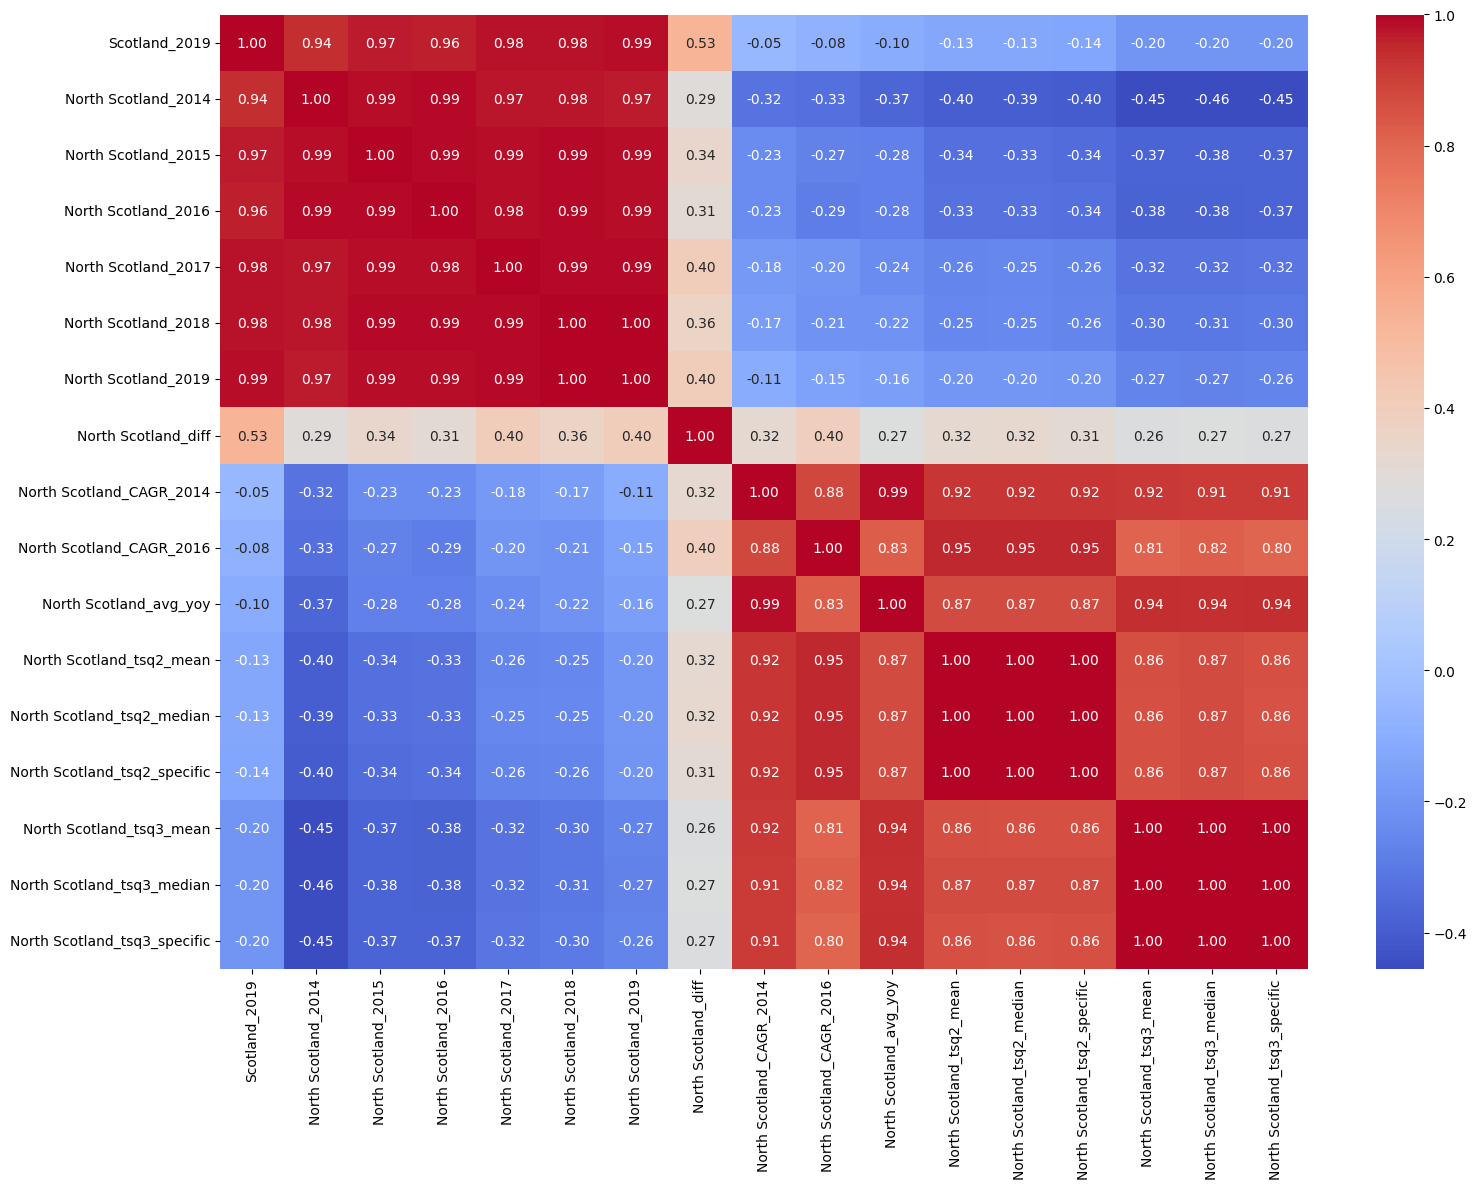

In [48]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    f_df.drop(columns=["Cause", f"{location}_inclusion_change"]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

### Table 2

In [49]:
diseases_f = list(set(f_df[(f_df[f"{location}_tsq2_median"] > threshold) | (f_df[f"{location}_diff"] < -20)]["Cause"].values.tolist()).union(set(f_df.iloc[:3]["Cause"].values.tolist())))
tab2_df = df1[(df1["Sex"] == "Female") & (df1["Cause"].isin(diseases_f))]
tab2_df.info()

<class 'pandas.DataFrame'>
Index: 1008 entries, 161736 to 319492
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       1008 non-null   int64
 1   Cause      1008 non-null   str  
 2   Location   1008 non-null   str  
 3   Age        1008 non-null   str  
 4   Sex        1008 non-null   str  
 5   DALY rate  1008 non-null   str  
dtypes: int64(1), str(5)
memory usage: 55.1 KB


In [50]:
tab2_df[(tab2_df["Year"]==2019) & (tab2_df["Location"] == location) & (tab2_df["Cause"] == "Breast cancer")]

,Year,Cause,Location,Age,Sex,DALY rate


In [51]:
tab2 = pd.pivot_table(tab2_df[(tab2_df["Year"]==2019) & (tab2_df["Location"] == location)], index="Cause", columns=["Age"], values="DALY rate", aggfunc="first").reset_index()
tab2.columns.name = None
cols = ["Cause", "All ages", "Under 15", "15 to 24", "25 to 44", "45 to 64", "65 to 84", "85 and over"]
tab2 = tab2[cols].sort_values(by="All ages", ascending=False).reset_index(drop=True)

for col in cols[1:]:
    tab2[col] = tab2[col].apply(lambda x: round(float(str(x).replace(",", ""))) if pd.notnull(x) else x)

tab2

,Cause,All ages,Under 15,15 to 24,25 to 44,45 to 64,65 to 84,85 and over
0,Alzheimer's disease and other dementias,1680,3,0,2,64,4461,36152
1,Ischaemic heart disease,1472,1,1,110,1050,4834,13694
2,Headache disorders,1354,326,1557,2161,1613,681,267
3,Lung cancer,1243,2,0,66,1514,4433,2811
4,Chronic obstructive pulmonary disease,1143,0,15,139,910,4305,5244
5,Other cancers,1030,17,5,582,1295,2643,3211
6,Drug use disorders,740,4,459,1942,616,52,8
7,Cirrhosis and other chronic liver diseases,454,1,4,377,928,611,155
8,Self-harm and interpersonal violence,441,9,1032,585,579,65,48
9,Skin and subcutaneous diseases,395,427,527,402,289,406,555


In [52]:
tab2.to_excel(f"{location}_tab2.xlsx", index=False)

### Table 4

In [53]:
diseases_m = list(set(m_df[(m_df[f"{location}_tsq2_median"] > threshold) | (m_df[f"{location}_diff"] < -20)]["Cause"].values.tolist()).union(set(m_df.iloc[:3]["Cause"].values.tolist())))
tab4_df = df1[(df1["Sex"] == "Male") & (df1["Cause"].isin(diseases_m))]
tab4_df.info()

<class 'pandas.DataFrame'>
Index: 924 entries, 161460 to 319446
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Year       924 non-null    int64
 1   Cause      924 non-null    str  
 2   Location   924 non-null    str  
 3   Age        924 non-null    str  
 4   Sex        924 non-null    str  
 5   DALY rate  924 non-null    str  
dtypes: int64(1), str(5)
memory usage: 50.5 KB


In [54]:
diseases_m

['Atrial fibrillation and flutter',
 'Ischaemic heart disease',
 'Lung cancer',
 'Other chronic respiratory diseases',
 'Drug use disorders',
 'Diabetes mellitus',
 'Self-harm and interpersonal violence',
 'Colorectal cancer',
 'Other cancers',
 "Alzheimer's disease and other dementias",
 'Oesophageal cancer']

In [55]:
tab4 = pd.pivot_table(tab4_df[(tab4_df["Year"]==2019) & (tab4_df["Location"] == location)], index="Cause", columns=["Age"], values="DALY rate", aggfunc="first").reset_index()
tab4.columns.name = None
cols = ["Cause", "All ages", "Under 15", "15 to 24", "25 to 44", "45 to 64", "65 to 84", "85 and over"]
tab4 = tab4[cols].sort_values(by="All ages", ascending=False).reset_index(drop=True)

for col in cols[1:]:
    tab4[col] = tab4[col].apply(lambda x: round(float(str(x).replace(",", ""))) if pd.notnull(x) else x)

tab4

,Cause,All ages,Under 15,15 to 24,25 to 44,45 to 64,65 to 84,85 and over
0,Ischaemic heart disease,3493,1,2,513,3773,10574,22363
1,Drug use disorders,1616,0,1392,3822,1590,116,75
2,Alzheimer's disease and other dementias,1578,0,0,1,175,4618,29853
3,Lung cancer,1557,0,0,99,1571,5721,5668
4,Self-harm and interpersonal violence,1235,2,1434,2256,1407,540,292
5,Other cancers,1208,77,107,506,1344,3678,2738
6,Diabetes mellitus,946,19,62,292,1204,2718,3108
7,Colorectal cancer,847,7,11,57,882,2841,4489
8,Oesophageal cancer,554,0,0,98,619,1954,1273
9,Atrial fibrillation and flutter,424,0,3,20,179,1444,4993


In [56]:
tab4.to_excel(f"{location}_tab4.xlsx", index=False)